<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

'wget' is not recognized as an internal or external command,
operable program or batch file.


#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [19]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = """
SELECT COUNT(*) AS total_rows
FROM main
"""

df = pd.read_sql_query(QUERY, conn)
print(df)

   total_rows
0       65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name  
FROM sqlite_master 
WHERE type = 'table'
"""
tables=pd.read_sql_query(QUERY, conn)
print(tables)

   name
0  main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


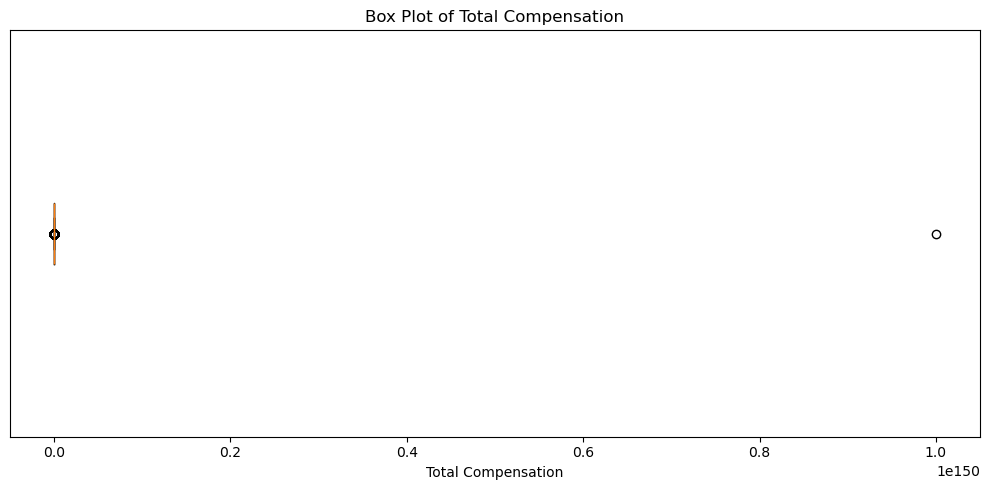

In [8]:
QUERY = """
SELECT CompTotal
FROM main
"""

comp_df = pd.read_sql_query(QUERY, conn)

# Convert compensation to numeric
comp_df["CompTotal"] = pd.to_numeric(
    comp_df["CompTotal"],
    errors="coerce"
)

plt.figure(figsize=(10, 5))

plt.boxplot(
    comp_df["CompTotal"].dropna(),
    orientation="horizontal",
    showfliers=True
)

plt.title("Box Plot of Total Compensation")
plt.xlabel("Total Compensation")
plt.yticks([])

plt.tight_layout()
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


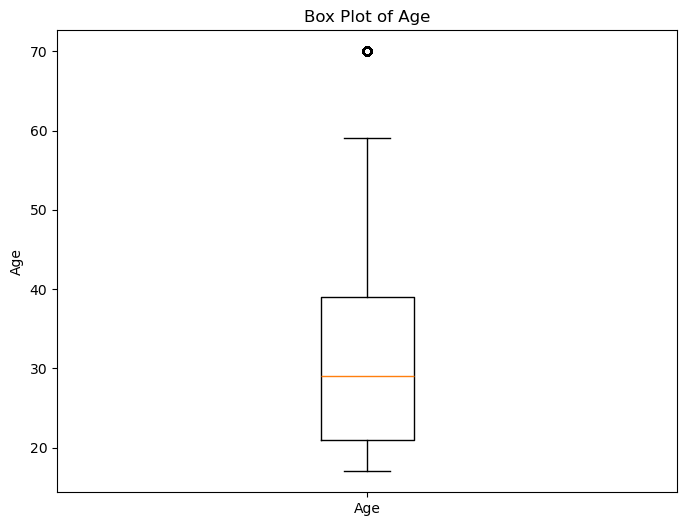

In [9]:
QUERY = """
SELECT Age
FROM main
"""

df = pd.read_sql_query(QUERY, conn)
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70,
    'Prefer not to say': None
}

# Create numeric Age column
df['Age_Numeric'] = df["Age"].map(age_mapping)

# Remove missing values
age_data = df['Age_Numeric'].dropna()

# Create box plot
plt.figure(figsize=(8, 6))

plt.boxplot(age_data)

plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.xticks([1], ["Age"])

plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


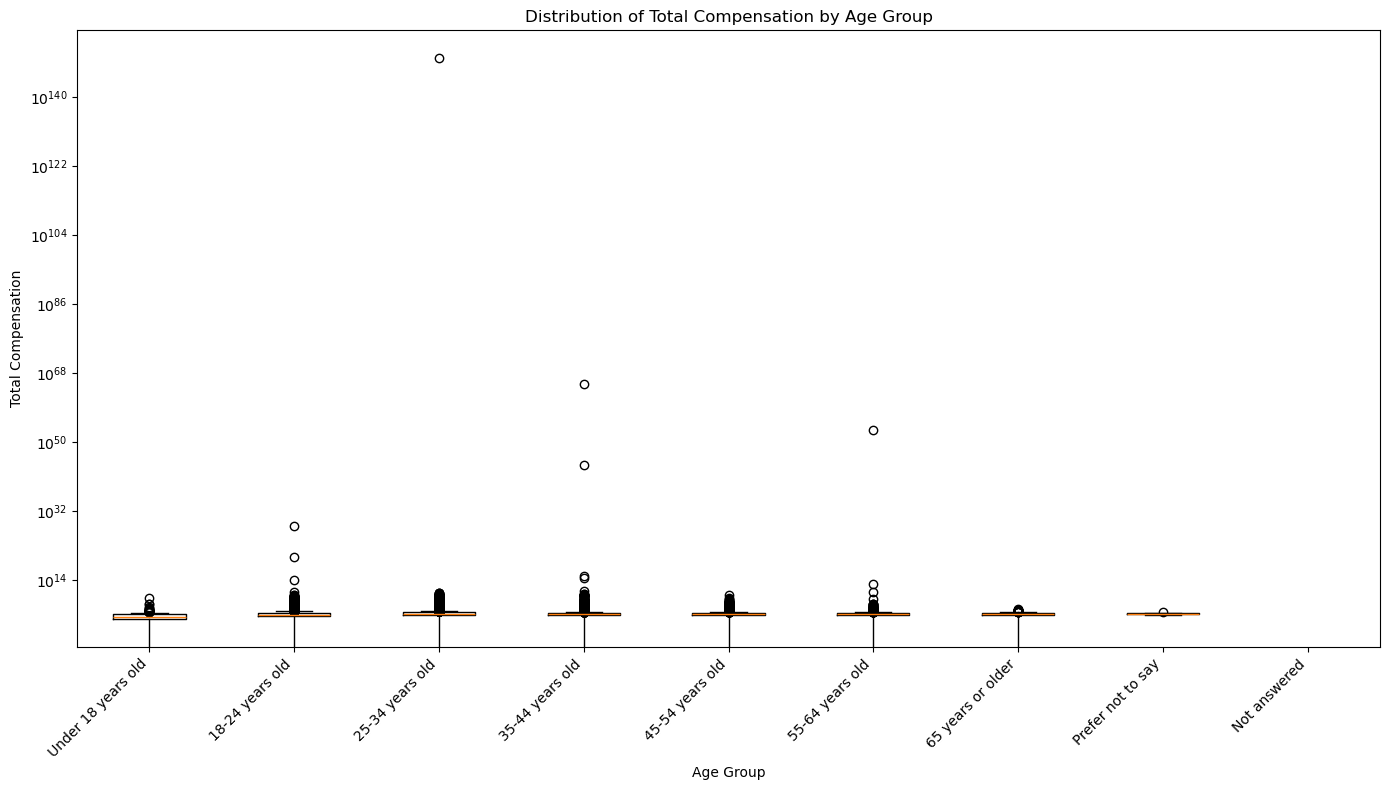

In [10]:
QUERY = """
SELECT Age, CompTotal
FROM main
"""

df = pd.read_sql_query(QUERY, conn)

# Convert compensation to numeric
df["CompTotal"] = pd.to_numeric(
    df["CompTotal"],
    errors="coerce"
)

# Keep missing age responses as a category
df["Age"] = df["Age"].fillna("Not answered")

age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
    "Prefer not to say",
    "Not answered"
]

boxplot_data = [
    df.loc[
        (df["Age"] == age_group) &
        (df["CompTotal"].notna()),
        "CompTotal"
    ]
    for age_group in age_order
]

plt.figure(figsize=(14, 8))

plt.boxplot(
    boxplot_data,
    tick_labels=age_order,
    orientation="vertical",
    showfliers=True
)

plt.yscale("log")

plt.title("Distribution of Total Compensation by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Compensation")

plt.xticks(rotation=45,ha="right")

plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


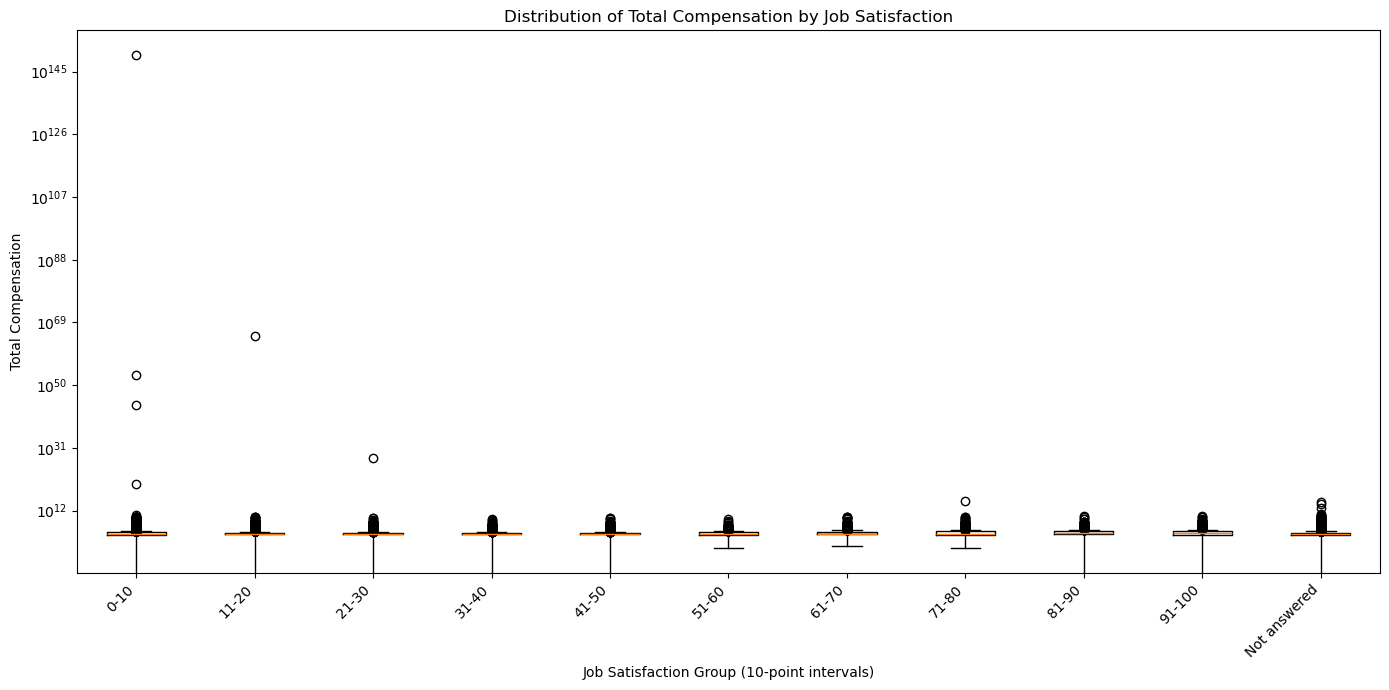

In [11]:
QUERY = """
SELECT JobSatPoints_6, CompTotal
FROM main
"""

df = pd.read_sql_query(QUERY, conn)

# Convert both columns to numeric
df["JobSatPoints_6"] = pd.to_numeric(
    df["JobSatPoints_6"],
    errors="coerce"
)

df["CompTotal"] = pd.to_numeric(
    df["CompTotal"],
    errors="coerce"
)

# Create job satisfaction groups of 10
df["JobSat_Group"] = pd.cut(
    df["JobSatPoints_6"],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    labels=[
        "0-10",
        "11-20",
        "21-30",
        "31-40",
        "41-50",
        "51-60",
        "61-70",
        "71-80",
        "81-90",
        "91-100"
    ],
    include_lowest=True
)

# Keep missing satisfaction values as a category
df["JobSat_Group"] = (
    df["JobSat_Group"]
    .astype("object")
    .fillna("Not answered")
)

# Order of groups
group_order = [
    "0-10",
    "11-20",
    "21-30",
    "31-40",
    "41-50",
    "51-60",
    "61-70",
    "71-80",
    "81-90",
    "91-100",
    "Not answered"
]

# Prepare data for boxplot
boxplot_data = [
    df.loc[
        (df["JobSat_Group"] == group) &
        (df["CompTotal"].notna()),
        "CompTotal"
    ]
    for group in group_order
]

plt.figure(figsize=(14, 7))

plt.boxplot(
    boxplot_data,
    tick_labels=group_order,
    orientation="vertical",
    showfliers=True
)

plt.yscale("log")

plt.title("Distribution of Total Compensation by Job Satisfaction")
plt.xlabel("Job Satisfaction Group (10-point intervals)")
plt.ylabel("Total Compensation")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


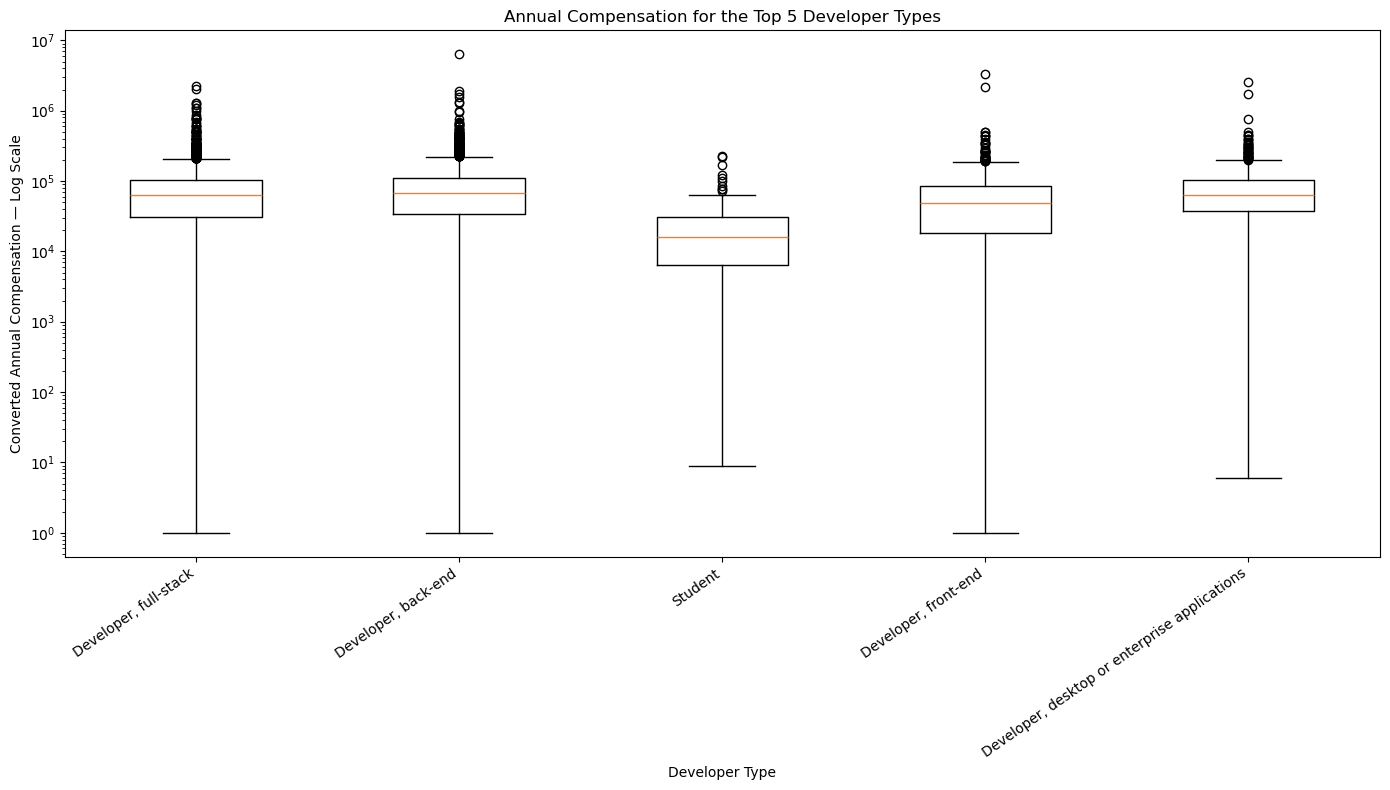

In [20]:
QUERY = """
SELECT DevType, ConvertedCompYearly
FROM main
"""

dev_df = pd.read_sql_query(QUERY, conn)

dev_df["ConvertedCompYearly"] = pd.to_numeric(
    dev_df["ConvertedCompYearly"],
    errors="coerce"
)

# Keep unanswered developer types as a category
dev_df["DevType"] = dev_df["DevType"].fillna("Not answered")

# Split multiple developer roles into separate rows
dev_df["DevType"] = dev_df["DevType"].str.split(";")
dev_expanded = dev_df.explode("DevType")

dev_expanded["DevType"] = dev_expanded["DevType"].str.strip()

top_5_developer_types = (
    dev_expanded.loc[
        dev_expanded["DevType"] != "Not answered",
        "DevType"
    ]
    .value_counts()
    .head(5)
    .index
)

boxplot_data = [
    dev_expanded.loc[
        (dev_expanded["DevType"] == developer_type) &
        (dev_expanded["ConvertedCompYearly"].notna()),
        "ConvertedCompYearly"
    ]
    for developer_type in top_5_developer_types
]
plt.figure(figsize=(14, 8))

plt.boxplot(
    boxplot_data,
    tick_labels=top_5_developer_types,
    orientation="vertical",
    showfliers=True
)

plt.yscale("log")

plt.title("Annual Compensation for the Top 5 Developer Types")
plt.xlabel("Developer Type")
plt.ylabel("Converted Annual Compensation — Log Scale")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


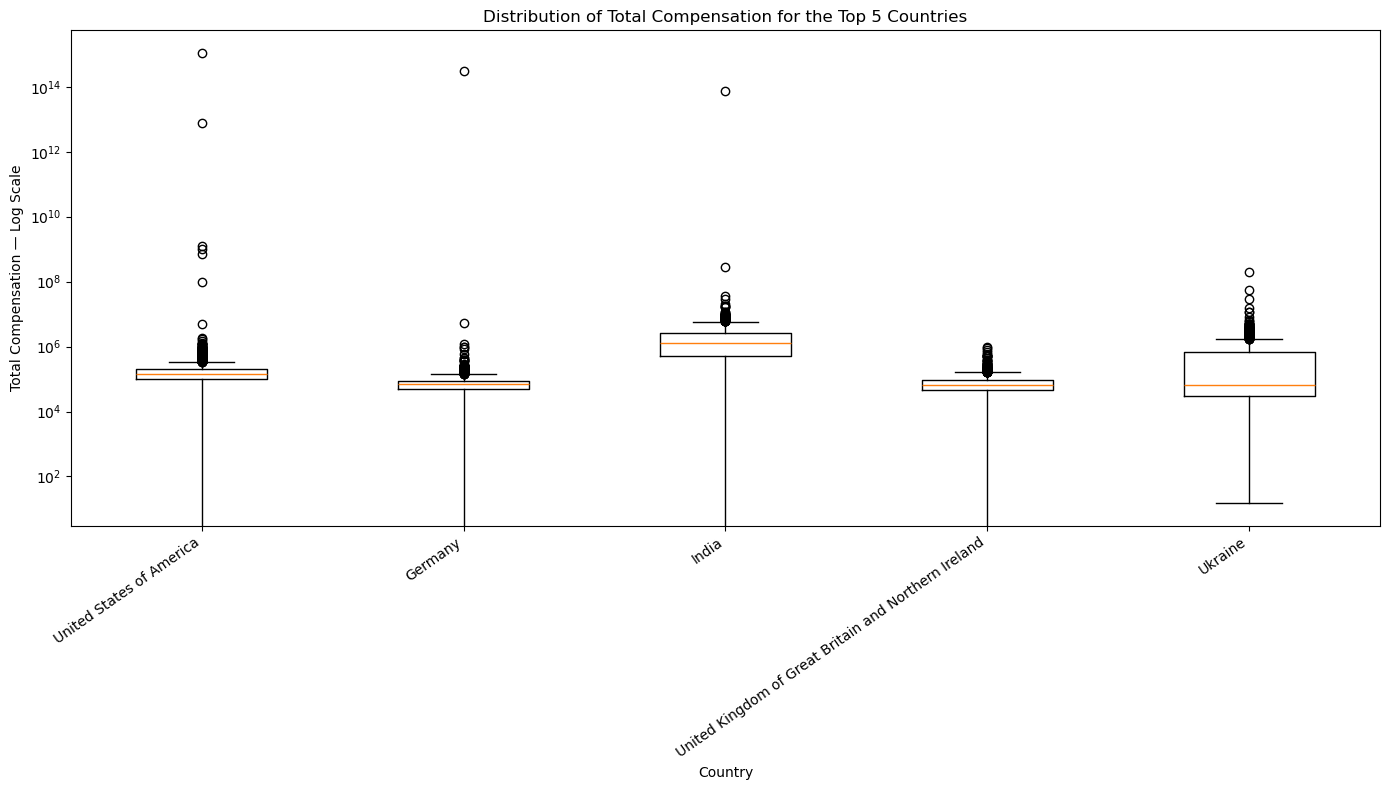

In [21]:
QUERY = """
SELECT Country, CompTotal
FROM main
"""

country_comp_df = pd.read_sql_query(QUERY, conn)

# Convert compensation to numeric
country_comp_df["CompTotal"] = pd.to_numeric(
    country_comp_df["CompTotal"],
    errors="coerce"
)

# Keep unanswered countries represented
country_comp_df["Country"] = (
    country_comp_df["Country"]
    .fillna("Not answered")
)

# Find the top 5 countries by number of respondents
top_5_countries = (
    country_comp_df.loc[
        country_comp_df["Country"] != "Not answered",
        "Country"
    ]
    .value_counts()
    .head(5)
    .index
)

boxplot_data = [
    country_comp_df.loc[
        (country_comp_df["Country"] == country) &
        (country_comp_df["CompTotal"].notna()),
        "CompTotal"
    ]
    for country in top_5_countries
]

plt.figure(figsize=(14, 8))

plt.boxplot(
    boxplot_data,
    tick_labels=top_5_countries,
    orientation="vertical",
    showfliers=True
)

plt.yscale("log")

plt.title("Distribution of Total Compensation for the Top 5 Countries")
plt.xlabel("Country")
plt.ylabel("Total Compensation — Log Scale")

plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


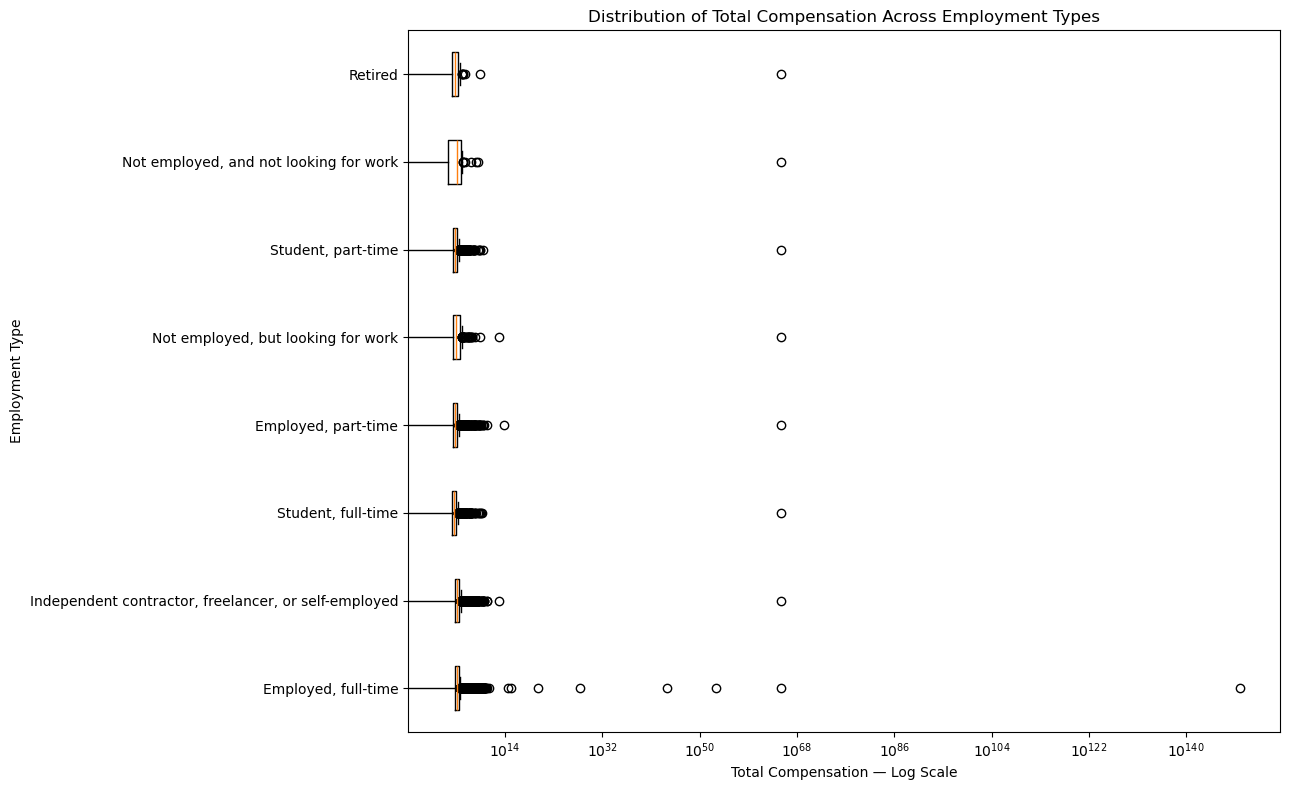

In [14]:
QUERY = """
SELECT Employment, CompTotal
FROM main
"""

employment_df = pd.read_sql_query(QUERY, conn)

# Convert compensation to numeric
employment_df["CompTotal"] = pd.to_numeric(
    employment_df["CompTotal"],
    errors="coerce"
)

# Keep missing employment responses represented
employment_df["Employment"] = (
    employment_df["Employment"]
    .fillna("Not answered")
)

# Split respondents with multiple employment types
employment_df["Employment"] = (
    employment_df["Employment"]
    .str.split(";")
)

employment_expanded = employment_df.explode("Employment")

employment_expanded["Employment"] = (
    employment_expanded["Employment"]
    .str.strip()
)

top_employment_types = (
    employment_expanded["Employment"]
    .value_counts()
    .head(8)
    .index
)

#print(top_employment_types)

boxplot_data = [
    employment_expanded.loc[
        (employment_expanded["Employment"] == employment_type) &
        (employment_expanded["CompTotal"].notna()),
        "CompTotal"
    ]
    for employment_type in top_employment_types
]
plt.figure(figsize=(13, 8))

plt.boxplot(
    boxplot_data,
    tick_labels=top_employment_types,
    orientation="horizontal",
    showfliers=True
)

plt.xscale("log")

plt.title("Distribution of Total Compensation Across Employment Types")
plt.xlabel("Total Compensation — Log Scale")
plt.ylabel("Employment Type")

plt.tight_layout()
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


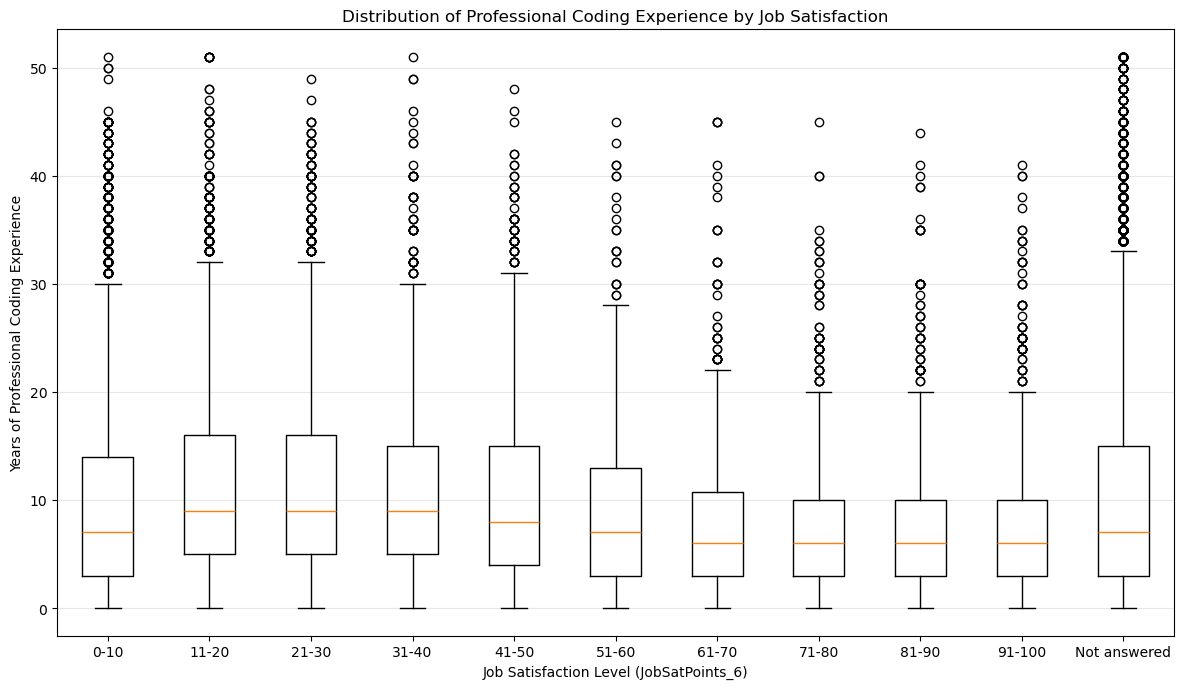

In [22]:
QUERY = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
"""

jobsat_df = pd.read_sql_query(QUERY, conn)

# Convert YearsCodePro to numeric
jobsat_df["YearsCodePro_Numeric"] = (
    jobsat_df["YearsCodePro"]
    .replace({
        "Less than 1 year": 0,
        "More than 50 years": 51
    })
)

jobsat_df["YearsCodePro_Numeric"] = pd.to_numeric(
    jobsat_df["YearsCodePro_Numeric"],
    errors="coerce"
)

# Convert JobSatPoints_6 to numeric
jobsat_df["JobSatPoints_6"] = pd.to_numeric(
    jobsat_df["JobSatPoints_6"],
    errors="coerce"
)

# Create job-satisfaction groups
jobsat_df["JobSat_Group"] = pd.cut(
    jobsat_df["JobSatPoints_6"],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    labels=[
        "0-10",
        "11-20",
        "21-30",
        "31-40",
        "41-50",
        "51-60",
        "61-70",
        "71-80",
        "81-90",
        "91-100"
    ],
    include_lowest=True
)

# Keep unanswered satisfaction values as a category
jobsat_df["JobSat_Group"] = (
    jobsat_df["JobSat_Group"]
    .astype("object")
    .fillna("Not answered")
)

group_order = [
    "0-10",
    "11-20",
    "21-30",
    "31-40",
    "41-50",
    "51-60",
    "61-70",
    "71-80",
    "81-90",
    "91-100",
    "Not answered"
]

# Prepare numeric values for each satisfaction group
boxplot_data = [
    jobsat_df.loc[
        (jobsat_df["JobSat_Group"] == group)
        & jobsat_df["YearsCodePro_Numeric"].notna(),
        "YearsCodePro_Numeric"
    ]
    for group in group_order
]

plt.figure(figsize=(12, 7))

plt.boxplot(
    boxplot_data,
    tick_labels=group_order,
    orientation="vertical",
    showfliers=True
)

plt.title(
    "Distribution of Professional Coding Experience "
    "by Job Satisfaction"
)
plt.xlabel("Job Satisfaction Level (JobSatPoints_6)")
plt.ylabel("Years of Professional Coding Experience")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [23]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
